****Day_20 Mini Project****

***TASK 01 Pick a dataset and frame a question***

• Choose a real dataset — from the approved list below, or bring your own (must be approved first).

• Frame ONE clear analytical question it can answer. Not 'explore the data' — a real question, like 'what factors
most affect X?' or 'do groups A and B differ in Y?'

**The Main Question For the Project:-“Which thing is more affected to be patient for Heart Diasease? & can we prove it ?"**

In [32]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

• Write two or three sentences on why the question matters and what you expect to find.

• Make sure the dataset is rich enough: at least a few hundred rows and several columns, with a mix of numeric
and categorical.


==>Heart disease and heart attacks are major health concerns.
This analysis will help us identify which factors are most strongly associated with heart disease and    
determine which factors have the greatest impact in our dataset.

***TASK 02 Load, clean, and run full EDA***

• Run the first-30-minutes checklist and document what you found.

In [33]:
df = pd.read_csv("heart_disease.csv")


print("shape" , df.shape)
print("\ncolumns:", list(df.columns))
print("\nmissing values:\n",df.isnull().sum()[df.isnull().sum() > 0] )

shape (10000, 21)

columns: ['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status']

missing values:
 Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level      

In [34]:
print("First 5 Rows of the Data",df.head())

First 5 Rows of the Data     Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep Hours  \
0       

In [35]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


• Clean the data: handle missing values (and justify your strategy), fix types, remove or flag outliers. Write down
every cleaning decision

In [77]:
print(df["Alcohol Consumption"].value_counts(dropna=False))
df["Alcohol Consumption"] = df["Alcohol Consumption"].fillna("None")

print("Missing values after fill:")
print(df["Alcohol Consumption"].isnull().sum())

# Check missing values after correcting Alcohol Consumption


print("Missing values after correction:")

print(df.isnull().sum()[df.isnull().sum() > 0])
# in this pandas taking none data as NaN so putting none instead of nan 


Alcohol Consumption
None      2586
Medium    2500
Low       2488
High      2426
Name: count, dtype: int64
Missing values after fill:
0
Missing values after correction:
Series([], dtype: int64)


In [39]:

#  Inspect missing categorical values

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Gender ---
Gender
Male      5003
Female    4978
NaN         19
Name: count, dtype: int64

--- Exercise Habits ---
Exercise Habits
High      3372
Medium    3332
Low       3271
NaN         25
Name: count, dtype: int64

--- Smoking ---
Smoking
Yes    5123
No     4852
NaN      25
Name: count, dtype: int64

--- Family Heart Disease ---
Family Heart Disease
No     5004
Yes    4975
NaN      21
Name: count, dtype: int64

--- Diabetes ---
Diabetes
No     5018
Yes    4952
NaN      30
Name: count, dtype: int64

--- High Blood Pressure ---
High Blood Pressure
Yes    5022
No     4952
NaN      26
Name: count, dtype: int64

--- Low HDL Cholesterol ---
Low HDL Cholesterol
Yes    5000
No     4975
NaN      25
Name: count, dtype: int64

--- High LDL Cholesterol ---
High LDL Cholesterol
No     5036
Yes    4938
NaN      26
Name: count, dtype: int64

--- Alcohol Consumption ---
Alcohol Consumption
None      2586
Medium    2500
Low       2488
High      2426
Name: count, dtype: int64

--- Stress Level --

C:\Users\morik\AppData\Local\Temp\ipykernel_33868\2066079124.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [61]:
# DECISION 2: Missing categorical values
# Each categorical column contains fewer than 0.3% missing values.
# Since the missing proportion is very small, we fill missing values
# with the mode (most frequent category) to retain all observations.

categorical_cols = [
    "Gender",
    "Exercise Habits",
    "Smoking",
    "Family Heart Disease",
    "Diabetes",
    "High Blood Pressure",
    "Low HDL Cholesterol",
    "High LDL Cholesterol",
    "Stress Level",
    "Sugar Consumption",
    "Alcohol Consumption"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing categorical values after filling:")
print(df[categorical_cols].isnull().sum())

Missing categorical values after filling:
Gender                  0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Stress Level            0
Sugar Consumption       0
Alcohol Consumption     0
dtype: int64


In [48]:
# DECISION 3: Inspect numerical variables before handling missing values

numeric_cols = [
    "Age",
    "Blood Pressure",
    "Cholesterol Level",
    "BMI",
    "Sleep Hours",
    "Triglyceride Level",
    "Fasting Blood Sugar",
    "CRP Level",
    "Homocysteine Level"
]

print(df[numeric_cols].describe().T , "\n")



# Check outliers using the IQR method

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f" {col}: {outliers} outliers")


    #No outliers were detected in the numerical variables using the 1.5 × IQR method. Therefore, no numerical observations were removed or modified for outlier treatment.

                       count        mean        std         min         25%  \
Age                  10000.0   49.296259  18.167567   18.000000   34.000000   
Blood Pressure       10000.0  149.757740  17.556265  120.000000  134.000000   
Cholesterol Level    10000.0  225.425577  43.510390  150.000000  187.000000   
BMI                  10000.0   29.077269   6.300156   18.002837   23.668887   
Sleep Hours          10000.0    6.991329   1.751002    4.000605    5.455288   
Triglyceride Level   10000.0  250.734409  86.953954  100.000000  176.000000   
Fasting Blood Sugar  10000.0  120.142213  23.558052   80.000000   99.000000   
CRP Level            10000.0    7.472201   4.334601    0.003647    3.681800   
Homocysteine Level   10000.0   12.456271   4.319100    5.000236    8.729771   

                            50%         75%         max  
Age                   49.000000   65.000000   80.000000  
Blood Pressure       150.000000  165.000000  180.000000  
Cholesterol Level    225.425577  26

In [45]:
# DECISION 3: Missing numerical values
# Numerical columns contain only a small number of missing values.
# No outliers were detected using the IQR method.
# Since the mean and median are very close, mean imputation is used
# to retain all observations.

numeric_cols = [
    "Age",
    "Blood Pressure",
    "Cholesterol Level",
    "BMI",
    "Sleep Hours",
    "Triglyceride Level",
    "Fasting Blood Sugar",
    "CRP Level",
    "Homocysteine Level"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("Missing numerical values after filling:")
print(df[numeric_cols].isnull().sum())

Missing numerical values after filling:
Age                    0
Blood Pressure         0
Cholesterol Level      0
BMI                    0
Sleep Hours            0
Triglyceride Level     0
Fasting Blood Sugar    0
CRP Level              0
Homocysteine Level     0
dtype: int64


In [50]:
# DECISION 4: Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

#No duplicate rows were found in the dataset. Therefore, no records were removed due to duplication.

Number of duplicate rows: 0


In [54]:
# DECISION 5: Final missing-value check

missing_after_cleaning = df.isnull().sum()

print("Remaining missing values:" , missing_after_cleaning[missing_after_cleaning > 0])

print("Duplicate rows:", df.duplicated().sum())
print("Final shape:", df.shape)

Remaining missing values: Series([], dtype: int64)
Duplicate rows: 0
Final shape: (10000, 21)


• Do univariate analysis on your key variables — distributions and shapes.

Heart Disease Status:
 Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Percentage:
 Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


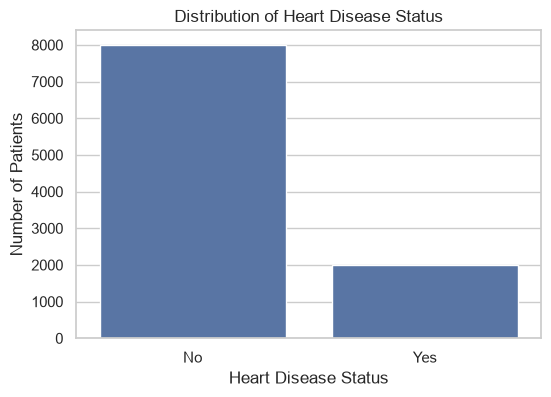

In [58]:
# EDA 1: Target variable distribution

print("Heart Disease Status:\n" , df["Heart Disease Status"].value_counts())

print("\nPercentage:\n" , df["Heart Disease Status"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Heart Disease Status"
)

plt.title("Distribution of Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

plt.show()


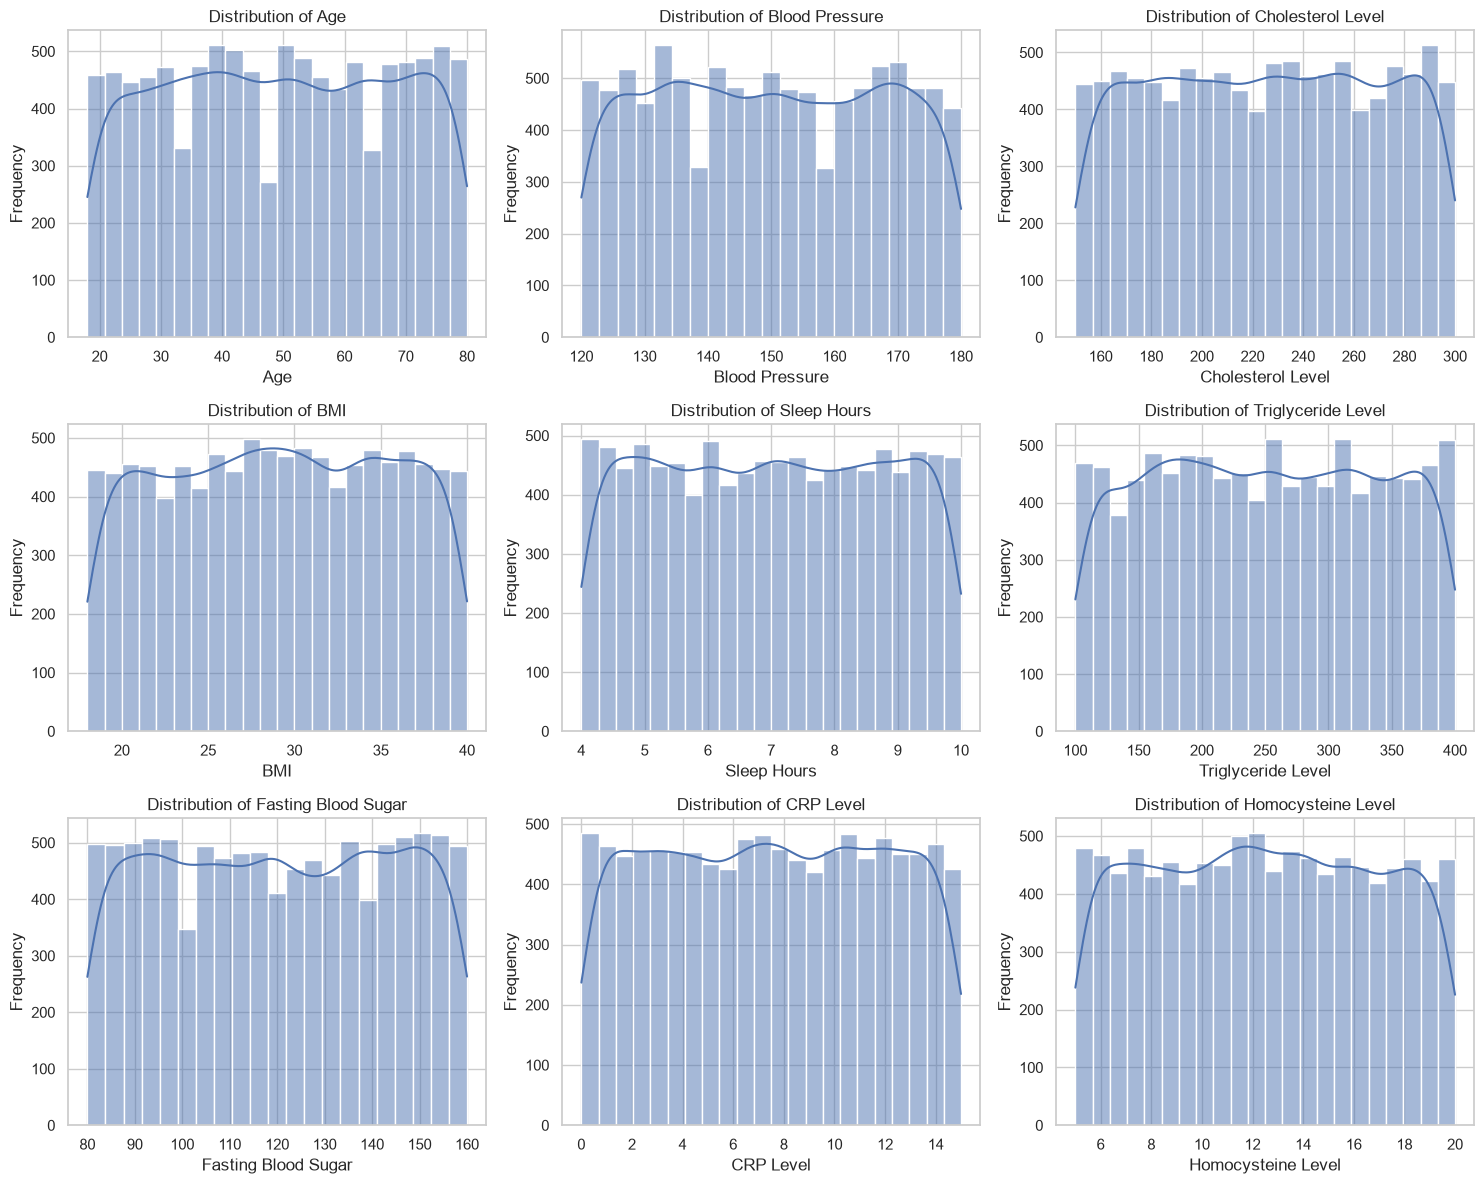

In [59]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

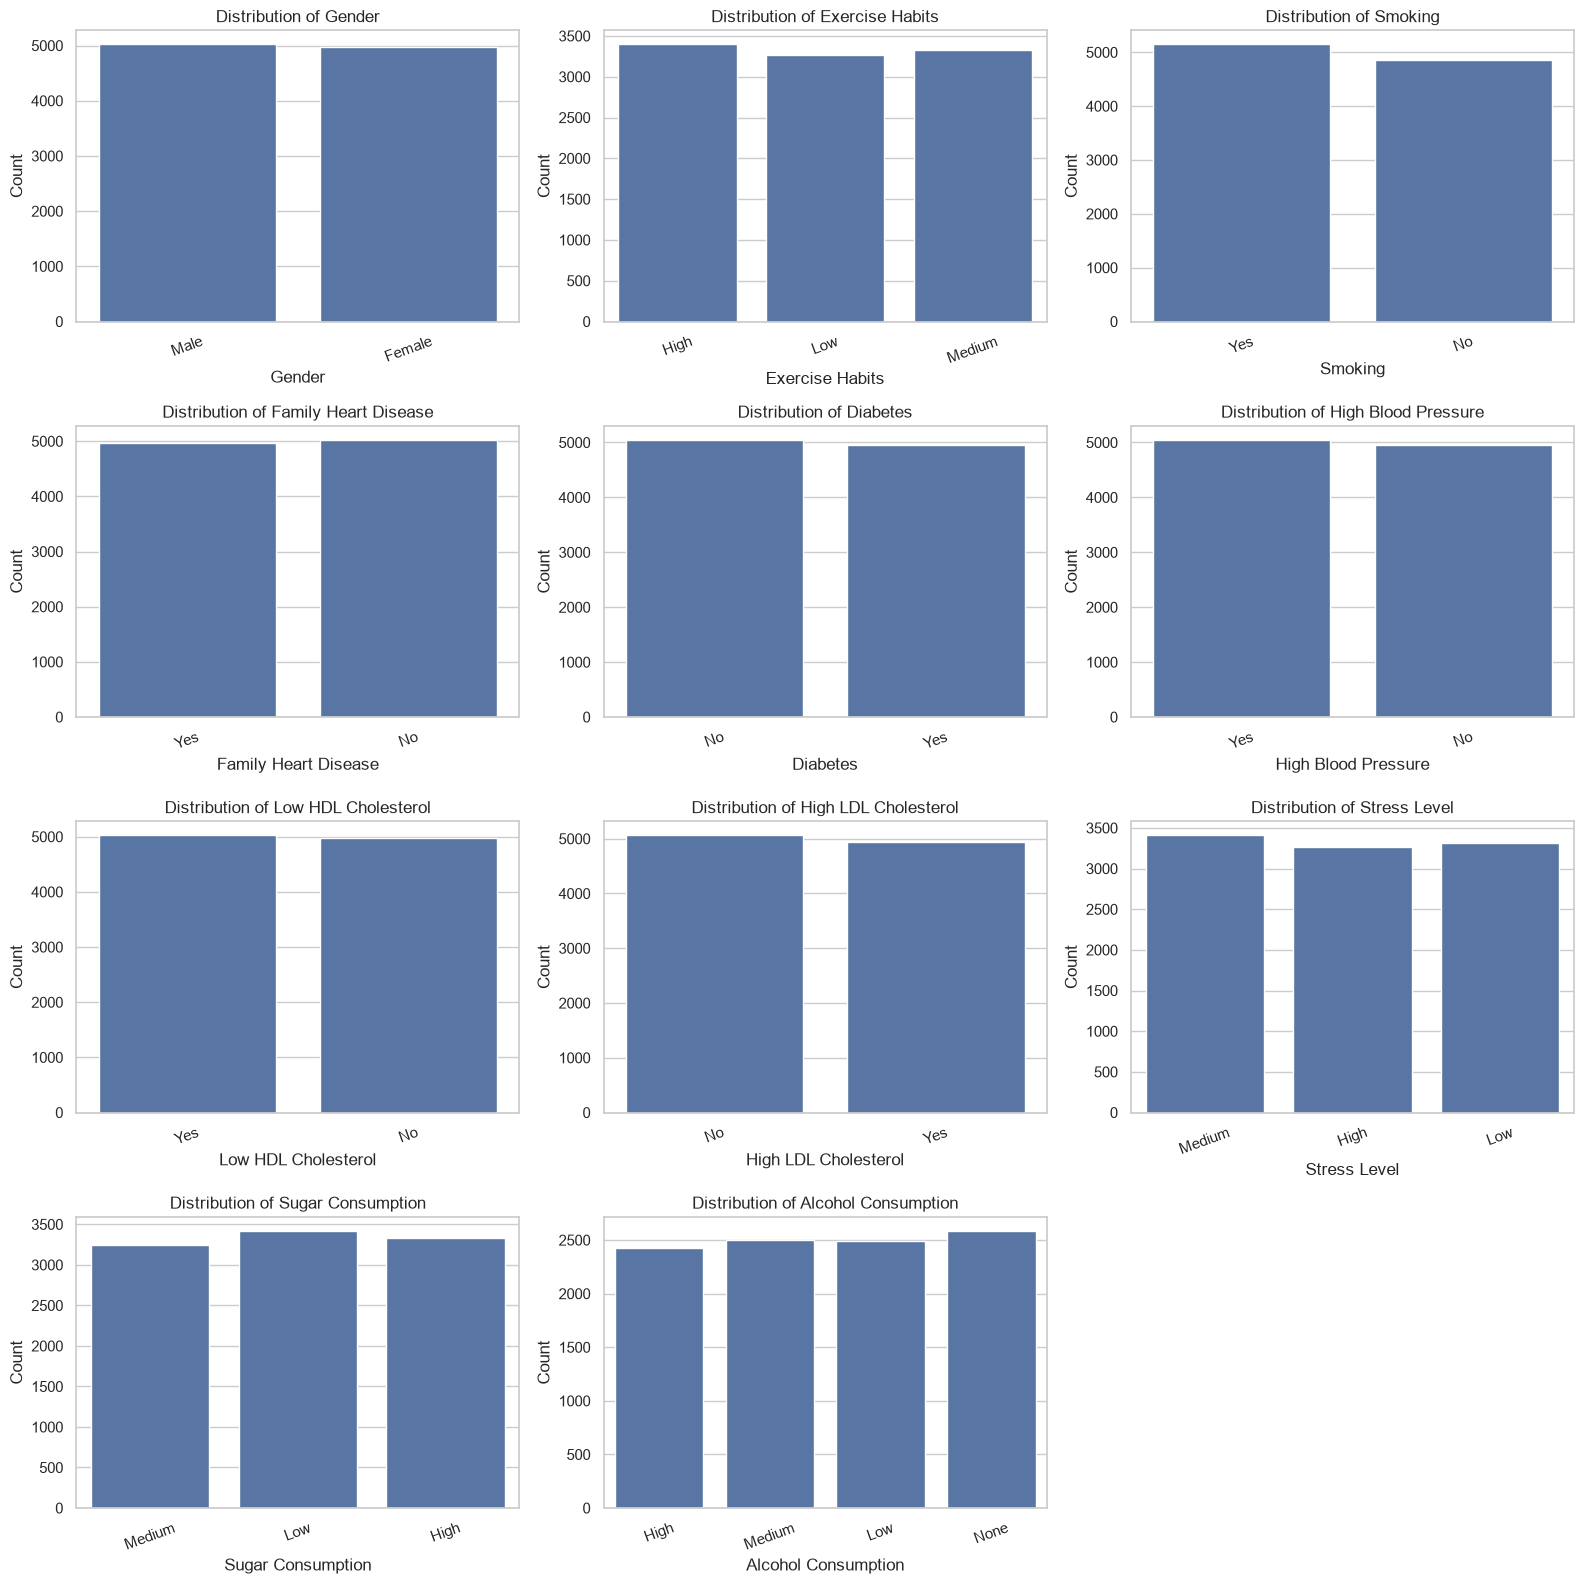

In [62]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)

# Hide unused subplot
for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

• Do bivariate and multivariate analysis — the relationships that bear on your question

In [65]:
for col in categorical_cols:
    print(f"\n--- {col} vs Heart Disease Status ---")
    print(
        pd.crosstab(
            df[col],
            df["Heart Disease Status"],
            normalize="index"
        ).mul(100).round(2)
    )

# Step 4.2 — Numeric variables vs Heart Disease Status

for col in numeric_cols:
    print(f"\n--- {col} vs Heart Disease Status ---")
    
    print(
        df.groupby("Heart Disease Status")[col]
        .agg(["mean", "median", "std"])
        .round(2)
    )


--- Gender vs Heart Disease Status ---
Heart Disease Status     No    Yes
Gender                            
Female                79.31  20.69
Male                  80.68  19.32

--- Exercise Habits vs Heart Disease Status ---
Heart Disease Status     No    Yes
Exercise Habits                   
High                  80.10  19.90
Low                   80.28  19.72
Medium                79.62  20.38

--- Smoking vs Heart Disease Status ---
Heart Disease Status     No    Yes
Smoking                           
No                    80.11  19.89
Yes                   79.90  20.10

--- Family Heart Disease vs Heart Disease Status ---
Heart Disease Status    No   Yes
Family Heart Disease            
No                    79.7  20.3
Yes                   80.3  19.7

--- Diabetes vs Heart Disease Status ---
Heart Disease Status     No    Yes
Diabetes                          
No                    79.89  20.11
Yes                   80.11  19.89

--- High Blood Pressure vs Heart Disease Statu

In [66]:
# Step 4.2 — Numeric variables vs Heart Disease Status

for col in numeric_cols:
    print(f"\n--- {col} vs Heart Disease Status ---")
    
    print(
        df.groupby("Heart Disease Status")[col]
        .agg(["mean", "median", "std"])
        .round(2)
    )


'''Bivariate Finding: Most factors show small differences in heart disease rates.
Stress Level and Alcohol Consumption show the largest differences, while numerical factors have very similar averages.
Statistical testing is needed to confirm these relationships.'''


--- Age vs Heart Disease Status ---
                       mean  median    std
Heart Disease Status                      
No                    49.38   49.15  18.19
Yes                   48.96   49.00  18.07

--- Blood Pressure vs Heart Disease Status ---
                        mean  median    std
Heart Disease Status                       
No                    149.88   150.0  17.58
Yes                   149.27   149.0  17.46

--- Cholesterol Level vs Heart Disease Status ---
                        mean  median    std
Heart Disease Status                       
No                    225.37  225.43  43.60
Yes                   225.66  226.00  43.16

--- BMI vs Heart Disease Status ---
                       mean  median   std
Heart Disease Status                     
No                    29.02   29.01  6.30
Yes                   29.33   29.47  6.28

--- Sleep Hours vs Heart Disease Status ---
                      mean  median   std
Heart Disease Status                    
No      

'Bivariate Finding: Most factors show small differences in heart disease rates.\nStress Level and Alcohol Consumption show the largest differences, while numerical factors have very similar averages.\nStatistical testing is needed to confirm these relationships.'

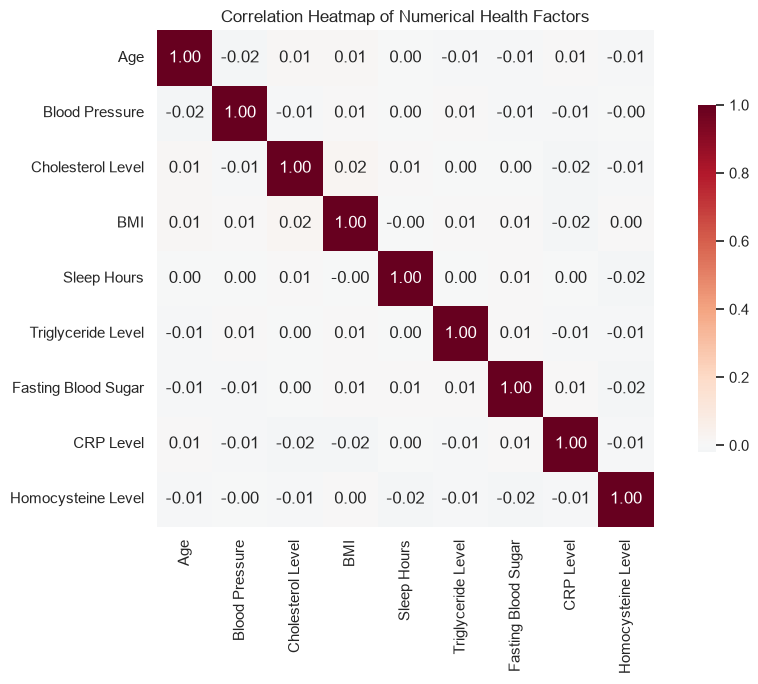

In [73]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.title("Correlation Heatmap of Numerical Health Factors")
plt.tight_layout()


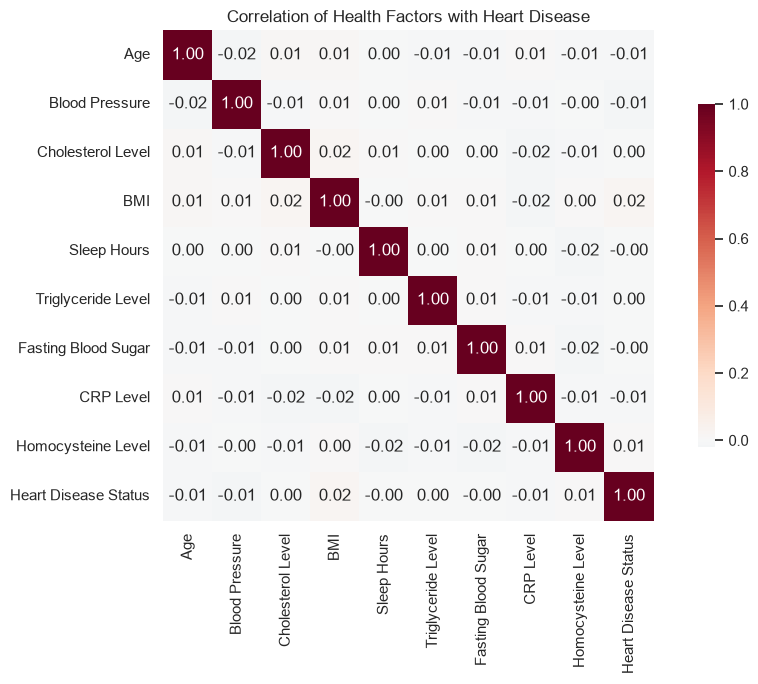

In [75]:
# Multivariate analysis including Heart Disease Status

df_corr = df.copy()

df_corr["Heart Disease Status"] = (
    df_corr["Heart Disease Status"] == "Yes"
).astype(int)

corr_cols = numeric_cols + ["Heart Disease Status"]

corr = df_corr[corr_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.title("Correlation of Health Factors with Heart Disease")
plt.tight_layout()
plt.show()

• Detect outliers systematically (boxplot and/or IQR), and decide what to do about them.

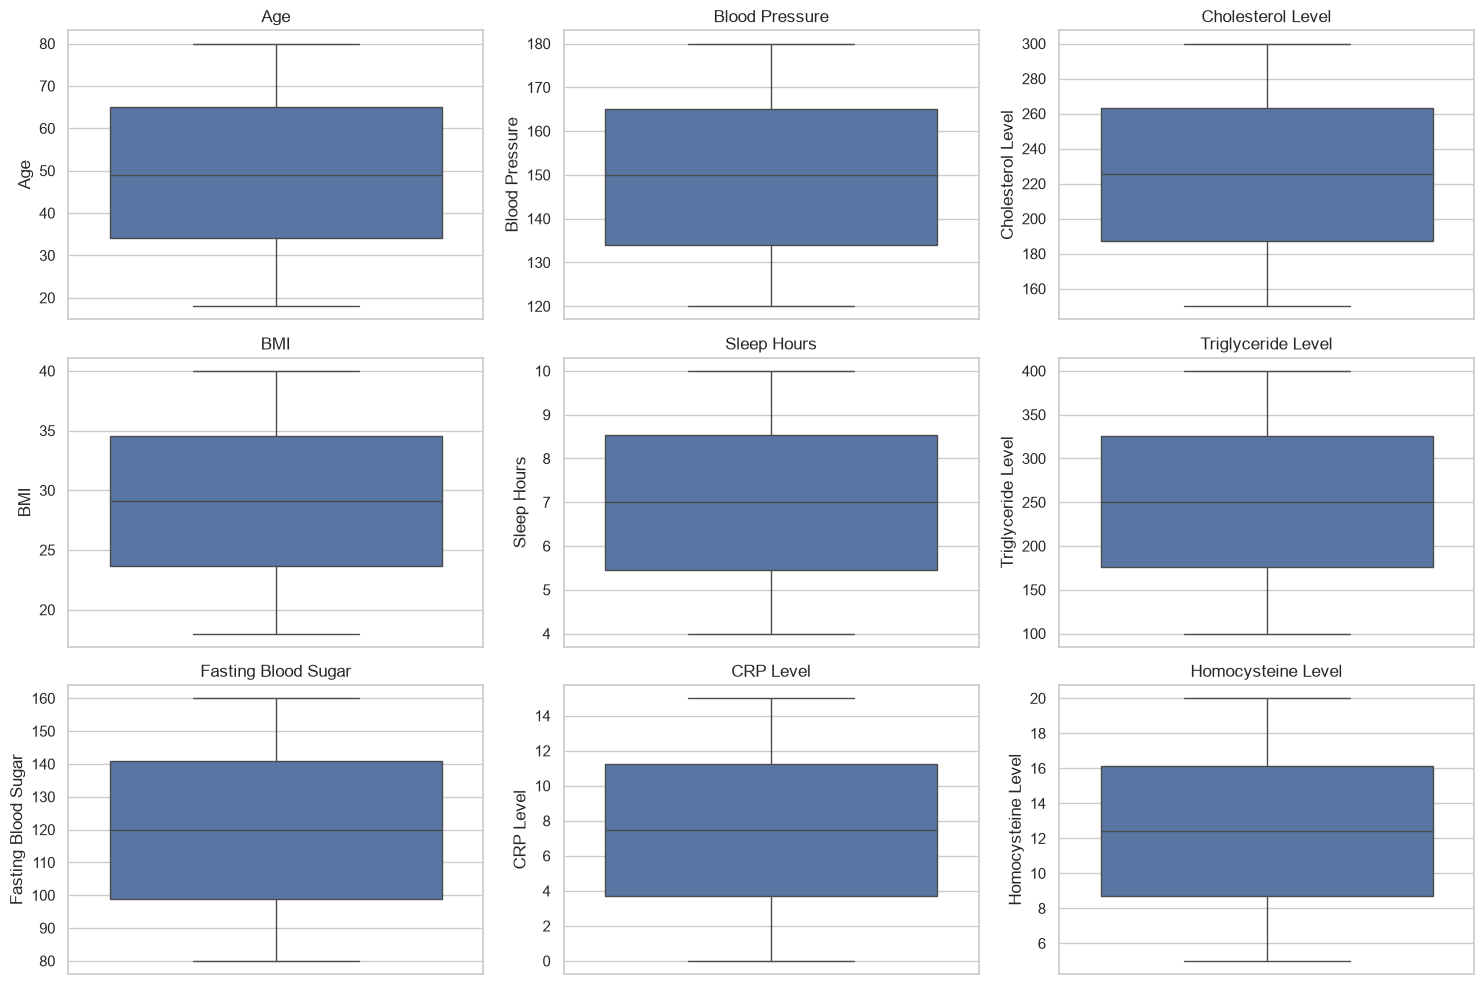

In [76]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()